In [1]:
#1.sentiment analysis(load data)
import pandas as pd

df=pd.read_csv("user_reviews.csv")
df=df[['Translated_Review','Sentiment']]

#drop null values
df.dropna(inplace=True)

print(df.head())

                                   Translated_Review Sentiment
0  I like eat delicious food. That's I'm cooking ...  Positive
1    This help eating healthy exercise regular basis  Positive
3         Works great especially going grocery store  Positive
4                                       Best idea us  Positive
5                                           Best way  Positive


In [2]:
#2.NLP(text preprocessing)
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words=set(stopwords.words('english'))

def clean_text(text):
    text=str(text)
    text=text.lower()
    text=re.sub(r'[^a-zA-Z]', ' ', text)
    words=text.split()
    words=[w for w in words if w not in stop_words]
    return " ".join(words)

#apply cleaning
df['Translated_Review']=df['Translated_Review'].astype(str)
df=df.dropna(subset=['Translated_Review'])

df['clean_text']=df['Translated_Review'].apply(clean_text)
print(df.head())


[nltk_data] Downloading package stopwords to C:\Users\vedashree k
[nltk_data]     a\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                   Translated_Review Sentiment  \
0  I like eat delicious food. That's I'm cooking ...  Positive   
1    This help eating healthy exercise regular basis  Positive   
3         Works great especially going grocery store  Positive   
4                                       Best idea us  Positive   
5                                           Best way  Positive   

                                          clean_text  
0  like eat delicious food cooking food case best...  
1         help eating healthy exercise regular basis  
3         works great especially going grocery store  
4                                       best idea us  
5                                           best way  


In [3]:
#3.feature enginerring(TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer=TfidfVectorizer(max_features=50000)

x=vectorizer.fit_transform(df['clean_text'])
y=df['Sentiment']
print(x.shape)

(37427, 19853)


In [4]:
#4.train-test=split
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
#5.machine laring model
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

model=MultinomialNB()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.6898209991985039


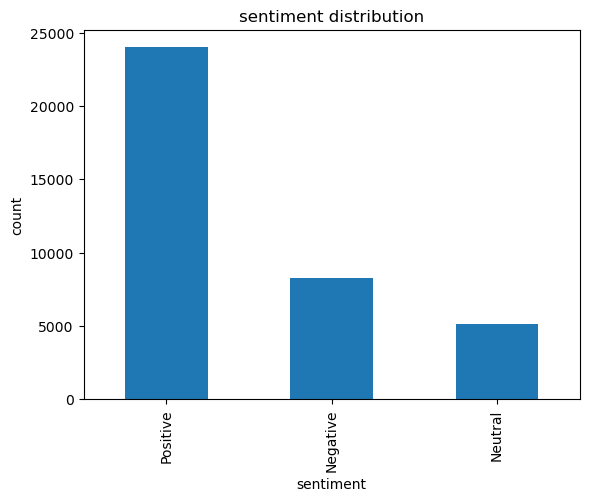

In [7]:
#6.data visulaization
import matplotlib.pyplot as plt

#sentiment count
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("sentiment distribution")
plt.xlabel("sentiment")
plt.ylabel("count")
plt.show()